# Evaluating a trained greyscale LNP model — Hoefling et al., 2024

Greyscale counterpart of `eval_hoefling_2024_lnp.ipynb`. It loads an **already trained**
linear-nonlinear-Poisson model whose core collapses the two stimulus colour channels (green, UV)
to their mean before the readout, so each neuron carries 1 x 18 x 16 = 288 weights instead of 576.
Nothing is trained here.

The default checkpoint is the `grey_smooth3e4` arm of job `442473` (`run_hoefling_lnp_grey.sh`):

| | value |
|---|---|
| `model.core.color_squashing_weights` | `[0.5, 0.5]` |
| `readout.smooth_weight` | `3e4` (the shipped default of `1.0` is numerically inert) |
| `readout.sparse_weight` | `1` |
| best val correlation | 0.0925 at epoch 51 |
| test correlation (trial-averaged) | 0.2563 |

How the four arms compare:

| model | val corr | test corr |
|---|---|---|
| grey, `smooth_weight=1` | 0.0926 | 0.2430 |
| grey, `smooth_weight=3e4` | 0.0925 | **0.2563** |
| colour, `smooth_weight=1` | 0.0860 | 0.2503 |
| colour, `smooth_weight=3e4` | 0.0983 | 0.2594 |

**Read the test column, not the val column.** Validation correlation here is single-trial and
noise-dominated: the two greyscale arms are indistinguishable on it (0.0926 vs 0.0925) yet differ
by 0.013 on the trial-averaged test set. Both `EarlyStopping` and `ModelCheckpoint` monitor the val
metric, so model selection cannot separate them. See `hoefling_2024_lnp_greyscale_plan.md`.

Data still has to be loaded — the stimuli and responses are what we evaluate against — but the
training, callbacks, logging and TensorBoard sections are all gone.

# Imports

In [1]:
import logging
import os

import hydra
import lightning
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from einops import rearrange

from openretina.data_io.base import compute_data_info
from openretina.data_io.cyclers import ShortCycler
from openretina.data_io.hoefling_2024.dataloaders import natmov_dataloaders_v2
from openretina.data_io.hoefling_2024.responses import filter_responses, make_final_responses
from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle
from openretina.eval.metrics import correlation_numpy, feve
from openretina.models.core_readout import load_core_readout_model
from openretina.utils.file_utils import get_cache_directory, get_local_file_path
from openretina.utils.h5_handling import load_h5_into_dict
from openretina.utils.misc import CustomPrettyPrinter

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pp = CustomPrettyPrinter(indent=4, max_lines=30)

## Memory check — run this first

Loading all 67 sessions peaks at about **4.5 GB** (measured on the batch runs). A VS Code SLURM
allocation is capped by its cgroup, and when the cap is exceeded the kernel is killed *silently* --
no traceback, just a dead kernel. This cell reports the cap up front so that failure is legible.

If it says the allocation is too small, relaunch the VS Code job with more memory, e.g.

```
sbatch -p cpu-ferranti -c 8 --mem=32G --qos=vs vscode/allocate-ferranti-vs.sh
```

In [2]:
from pathlib import Path


def cgroup_memory_limit_gb() -> float | None:
    """Effective memory ceiling of the enclosing cgroup, or None if unlimited/unknown.

    Under SLURM the cap sits on an ancestor cgroup (the job scope), not on the leaf the process
    lives in, so we take the minimum over the whole chain up to the root.
    """
    try:
        rel = next(
            line.split(":", 2)[2].strip()
            for line in open("/proc/self/cgroup")
            if line.startswith("0::")
        )
    except (OSError, StopIteration):
        try:  # cgroup v1
            value = int(open("/sys/fs/cgroup/memory/memory.limit_in_bytes").read())
            return value / 1024**3 if value < 2**62 else None
        except OSError:
            return None

    root, path, limits = Path("/sys/fs/cgroup"), Path("/sys/fs/cgroup") / rel.lstrip("/"), []
    while True:
        try:
            raw = (path / "memory.max").read_text().strip()
            if raw != "max":
                limits.append(int(raw))
        except OSError:
            pass
        if path == root:
            break
        path = path.parent
    return min(limits) / 1024**3 if limits else None


NEEDED_GB = 4.5  # peak RSS of the full 67-session load, measured on the batch runs

limit_gb = cgroup_memory_limit_gb()
if limit_gb is None:
    print("no cgroup memory cap found; assuming this is not a capped allocation")
else:
    print(f"allocation memory cap: {limit_gb:.1f} GB (this notebook needs ~{NEEDED_GB} GB)")
    if limit_gb < NEEDED_GB * 1.5:
        raise MemoryError(
            f"This allocation caps memory at {limit_gb:.1f} GB, but loading all sessions peaks at "
            f"~{NEEDED_GB} GB. The kernel would be killed without a traceback part-way through the "
            f"data cells. Relaunch the VS Code job with --mem=32G (see the cell above), or run the "
            f"evaluation as a batch job instead."
        )


allocation memory cap: 16.0 GB (this notebook needs ~4.5 GB)


# Config and paths

We compose the same config the model was trained with, so the data loading matches exactly.

In [3]:
with hydra.initialize(config_path=os.path.join("..", "configs"), version_base="1.3"):
    cfg = hydra.compose(config_name="hoefling_2024_core_readout_low_res_lnp_grey.yaml")

CACHE_DIR = os.environ.get("OPENRETINA_CACHE_DIRECTORY") or get_cache_directory()
cfg.paths.cache_dir = CACHE_DIR
os.environ["OPENRETINA_CACHE_DIRECTORY"] = CACHE_DIR

# `paths.output_dir` defaults to `${hydra:runtime.output_dir}`, which only resolves inside a hydra
# job. We compose by hand here, so point it somewhere concrete.
cfg.paths.log_dir = "."
cfg.paths.output_dir = "."

print(f"cache: {CACHE_DIR}")

cache: /weka/bethge/bkr578/openretina_cache


# Data

Same three steps as in the training notebook: stimuli, responses, dataloaders. This is the slow
part of the notebook (a couple of minutes and a few GB of RAM for all 67 sessions).

In [4]:
movies_path = get_local_file_path(file_path=cfg.paths.movies_path, cache_folder=cfg.paths.data_dir)
movies_dict = movies_from_pickle(movies_path)

pp.pprint(movies_dict)

2026-08-25 15:25:20,429 - INFO - Fetching file list for open-retina/open-retina...


2026-08-25 15:25:20,618 - INFO - Found target file at /weka/bethge/bkr578/openretina_cache/data/euler_lab/hoefling_2024/stimuli/rgc_natstim_18x16_joint_normalized_2024-01-11.pkl


MoviesTrainTestSplit(train=numpy.ndarray(shape=(2, 16200, 18, 16)),
                     test_dict={   'test': numpy.ndarray(shape=(2, 750, 18, 16))},
                     stim_id=None,
                     random_sequences=numpy.ndarray(shape=(108, 20)),
                     norm_mean=nan,
                     norm_std=nan)


In [5]:
responses_path = get_local_file_path(file_path=cfg.paths.responses_path, cache_folder=cfg.paths.data_dir)

responses_dict = load_h5_into_dict(file_path=responses_path)
filtered_responses_dict = filter_responses(responses_dict, **cfg.quality_checks)
final_responses = make_final_responses(filtered_responses_dict, response_type="natural")

print(f"{len(final_responses)} sessions")

2026-08-25 15:25:20,981 - INFO - Fetching file list for open-retina/open-retina...


2026-08-25 15:25:21,120 - INFO - Found target file at /weka/bethge/bkr578/openretina_cache/data/euler_lab/hoefling_2024/responses/rgc_natstim_2024-08-14.h5


Loading HDF5 file contents:   0%|          | 0/2077 [00:00<?, ?item/s]

Original dataset contains 7863 neurons over 67 fields
 ------------------------------------ 


Dropped 0 fields that did not contain the target cell types (67 remaining)
Overall, dropped 3034 neurons of non-target cell types (-38.59%).
 ------------------------------------ 


Dropped 0 fields with quality indices below threshold (67 remaining)
Overall, dropped 980 neurons over quality checks (-20.29%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 705 neurons with classifier confidences below 0.25 (-18.32%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 3144 neurons over 67 fields
Total number of cells dropped: 4719 (-60.02%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/67 [00:00<?, ?it/s]

67 sessions


In [6]:
dataloaders = natmov_dataloaders_v2(
    neuron_data_dictionary=final_responses,
    movies_dictionary=movies_dict,
    allow_over_boundaries=True,
    batch_size=cfg.dataloader.batch_size,
    train_chunk_size=cfg.dataloader.train_chunk_size,
    validation_clip_indices=cfg.dataloader.validation_clip_indices,
)

data_info = compute_data_info(neuron_data_dictionary=final_responses, movies_dictionary=movies_dict)

print(f"{sum(data_info['n_neurons_dict'].values())} neurons over {len(data_info['n_neurons_dict'])} sessions")

Creating movie dataloaders:   0%|          | 0/67 [00:00<?, ?it/s]

3144 neurons over 67 sessions


# Loading the trained model

`load_core_readout_model` restores a `UnifiedCoreReadout` (weights, hyperparameters and the
`data_info` recorded at training time) from a checkpoint. It accepts a local path, a path relative
to the openretina cache, or the name of one of the published models.

In [7]:
# The `_final` checkpoint is the one written after `trainer.test`; it carries the test-time
# `data_info` (performance metrics, `model_cut_frames`) in addition to the weights.
CKPT_PATH = (
    "../openretina_assets/runs/lnp_grey/442473/grey_smooth3e4/checkpoints/"
    "epoch=51_val_evaluation_loss=0.093_final.ckpt"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_core_readout_model(CKPT_PATH, device)
model.eval()

example_readout = model.readout[next(iter(model.readout.keys()))]
print(f"{type(model).__name__} on {device}")
print(f"  readout              {type(model.readout).__name__}, {len(model.readout.keys())} sessions")
print(f"  smooth / sparse      {example_readout.smooth_weight} / {example_readout.sparse_weight}")
print(f"  learning rate        {model.learning_rate}")
print(f"  trainable parameters {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

UnifiedCoreReadout on cpu
  readout              MultipleLNPReadout, 67 sessions
  smooth / sparse      30000.0 / 1.0
  learning rate        0.005
  trainable parameters 908,616


## Is this actually a greyscale model?

Worth checking explicitly. The readout's channel count is *derived* by probing the core at
construction time, never declared in the config, so the only way to confirm from a checkpoint
alone that the squash really happened is to look at the core layer and the readout kernel.

In [8]:
squash = model.core.color_squashing_layer
kernel = example_readout.inner_product_kernel.weight

print(f"core squashing layer  {squash}")
print(f"channel weights       {None if squash is None else squash.channel_weights.tolist()}")
print(f"readout in_channels   {example_readout.in_channels}")
print(f"readout kernel        {tuple(kernel.shape)}  ->  {kernel[0].numel()} weights/neuron")
print(f"stimulus it expects   {model.stimulus_shape(time_steps=150)}  (still 2-channel: the squash is internal)")

assert squash is not None, "this checkpoint has no colour squashing - it is a COLOUR model"
assert example_readout.in_channels == 1, f"expected 1 readout channel, got {example_readout.in_channels}"
assert kernel[0].numel() == 18 * 16, "unexpected kernel size"
print("\nconfirmed greyscale: 288 weights/neuron, half the colour model")


core squashing layer  WeightedChannelSumLayer()
channel weights       [0.5, 0.5]
readout in_channels   1
readout kernel        (80, 1, 1, 18, 16)  ->  288 weights/neuron
stimulus it expects   (1, 2, 150, 18, 16)  (still 2-channel: the squash is internal)

confirmed greyscale: 288 weights/neuron, half the colour model


What the model recorded about itself at training time:

In [9]:
for key in ("pretrained_performance_metric", "pretrained_performance", "model_cut_frames", "input_shape"):
    if key in model.data_info:
        print(f"{key:32s} {model.data_info[key]}")

pretrained_performance_metric    test CorrelationLoss3d
pretrained_performance           {'session_1_ventral1_20200226': tensor([ 0.2613,  0.3357,  0.1535,  0.0744,  0.2666,  0.4515,  0.3959,  0.1209,
         0.2048,  0.1617, -0.1198,  0.3583,  0.0321,  0.0025,  0.4178, -0.4803,
         0.2088,  0.1071,  0.1782,  0.2571,  0.4378,  0.2191,  0.2790, -0.0992,
        -0.0348,  0.5884,  0.1662,  0.0075,  0.3829,  0.4083,  0.2566,  0.4425,
         0.2849, -0.1539,  0.3019,  0.4969,  0.0159,  0.1776,  0.0318,  0.1722,
         0.1932,  0.3468,  0.2804,  0.0213,  0.3958,  0.2654,  0.5274,  0.4543,
         0.1998,  0.3786,  0.2387,  0.0692,  0.3723,  0.1643, -0.1164,  0.1316,
         0.3552,  0.5031,  0.2207,  0.4286,  0.4858,  0.4605,  0.3992,  0.3472,
         0.3629,  0.3709,  0.1529,  0.2226,  0.2960,  0.0851,  0.0131,  0.1634,
         0.0808,  0.2407,  0.3327, -0.2833,  0.4484,  0.2395,  0.1601,  0.3622]), 'session_1_ventral1_20200528': tensor([ 0.0283,  0.6017,  0.0920,  0.2387,  0

A checkpoint only makes sense against the sessions it was trained on — the readout is
session-specific. Check that the loaded model and the data we just built agree:

In [10]:
model_sessions = set(model.readout.keys())
data_sessions = set(data_info["n_neurons_dict"].keys())

print(f"model {len(model_sessions)} sessions, data {len(data_sessions)} sessions")
print(f"only in model: {sorted(model_sessions - data_sessions)}")
print(f"only in data:  {sorted(data_sessions - model_sessions)}")
assert model_sessions == data_sessions, "checkpoint and data do not describe the same sessions"

mismatched = {
    k: (model.readout[k].number_of_neurons(), data_info["n_neurons_dict"][k])
    for k in sorted(model_sessions)
    if model.readout[k].number_of_neurons() != data_info["n_neurons_dict"][k]
}
print(f"neuron-count mismatches: {mismatched if mismatched else 'none'}")

model 67 sessions, data 67 sessions
only in model: []
only in data:  []
neuron-count mismatches: none


# Quantitative evaluation

The same numbers `openretina train` prints at the end of training: Poisson loss and correlation on
each split. `CorrelationLoss3d` is the average correlation per neuron (higher is better), and is
what early stopping and the LR scheduler monitor during training.

In [11]:
loaders = {name: ShortCycler(dataloaders[name]) for name in ("train", "validation", "test")}
print({f"DataLoader {i}": name for i, name in enumerate(loaders)})

# logger=False / enable_checkpointing=False: we are only reading metrics out, and without a
# checkpoint callback the model's `on_test_end` hook will not write a stray `_final.ckpt`.
trainer = lightning.Trainer(logger=False, enable_checkpointing=False, accelerator="auto", devices=1)
test_results = trainer.test(model, dataloaders=list(loaders.values()))

/weka/bethge/bkr578/projects/open-retina/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /weka/bethge/bkr578/projects/open-retina/.venv/lib64 ...
GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


{'DataLoader 0': 'train', 'DataLoader 1': 'validation', 'DataLoader 2': 'test'}


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     CorrelationLoss3d     │    0.06807685643434525    │    0.09253362566232681    │    0.25628745555877686    │
│       PoissonLoss3d       │     482.0522766113281     │     375.3878173828125     │    36.417625427246094     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

# Fraction of explainable variance explained

Correlation does not tell us how much of the *explainable* (i.e. non-noise) variance the model
captures. FEVe does, using the repeated presentations of the test clip.

In [12]:
example_session = sorted(final_responses.keys())[1]

responses_by_trial = final_responses[example_session].test_by_trial  # (neurons, time, trials)
test_movie = dataloaders["test"][example_session].dataset.movies

with torch.no_grad():
    model_predictions = model(test_movie.to(model.device).unsqueeze(0), data_key=example_session)
model_predictions = model_predictions.squeeze(0).cpu().numpy()  # (time, neurons)

# The core drops the first frames, so the targets have to be trimmed by the same amount.
lag = responses_by_trial.shape[1] - model_predictions.shape[0]
print(f"session {example_session}: {responses_by_trial.shape} responses, "
      f"{model_predictions.shape} predictions, lag {lag} frames")

feve_score = feve(
    rearrange(responses_by_trial, "neurons time trials -> time trials neurons")[lag:],
    model_predictions,
)
correlations = correlation_numpy(
    final_responses[example_session].test_response.T[lag:], model_predictions, axis=0
)

print(f"mean FEVe        {feve_score.mean():.3f}")
print(f"mean correlation {correlations.mean():.3f}")

session session_1_ventral1_20200528: (42, 750, 3) responses, (720, 42) predictions, lag 30 frames
mean FEVe        0.080
mean correlation 0.317


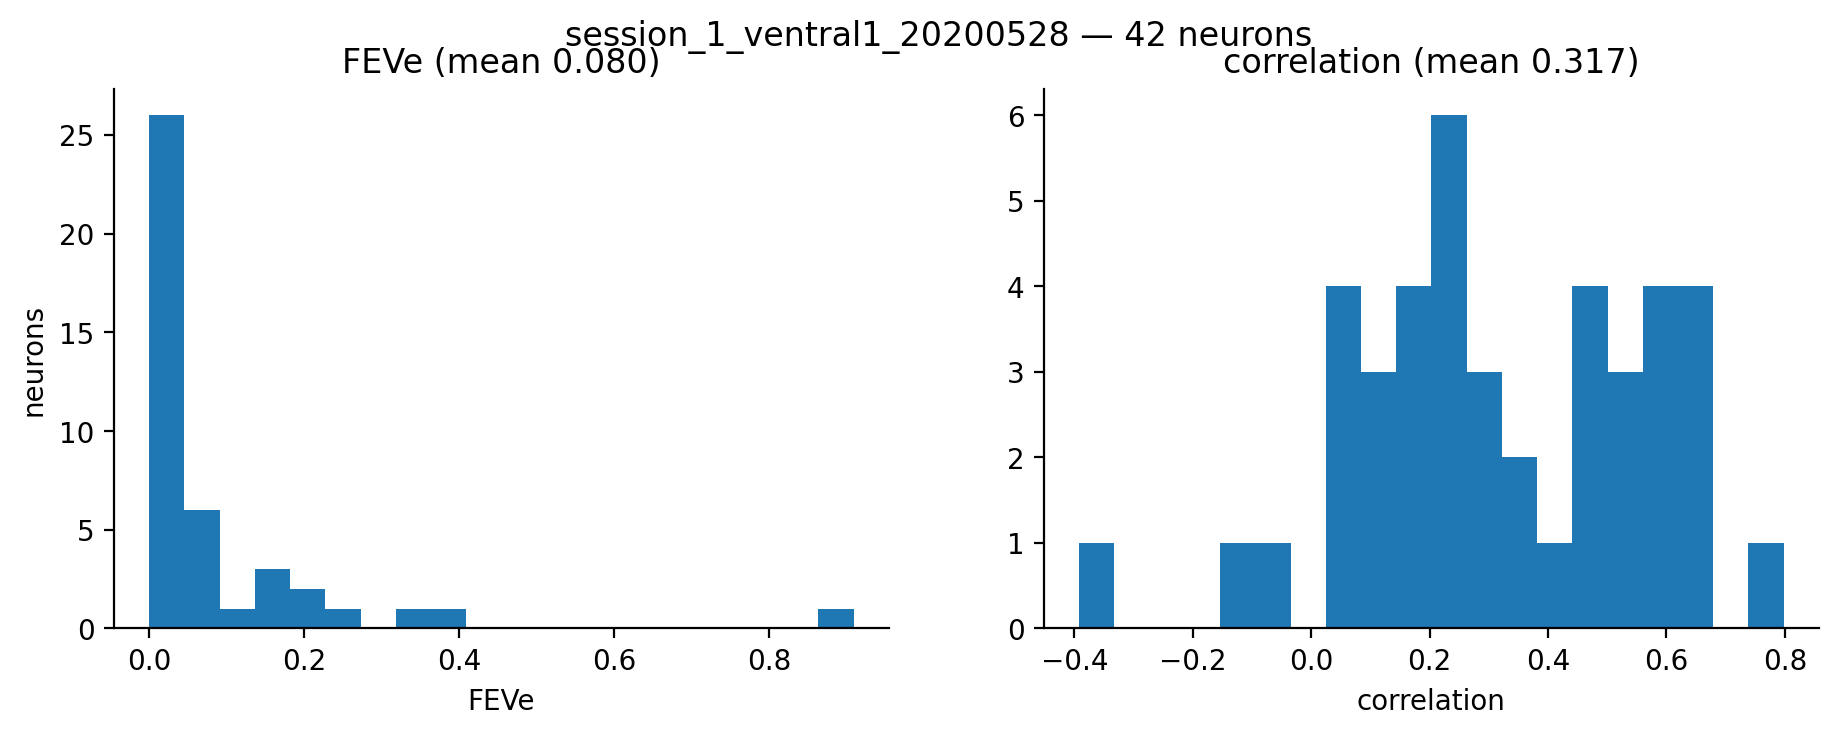

In [13]:
fig, (ax_feve, ax_corr) = plt.subplots(ncols=2, figsize=(11, 3.5))
ax_feve.hist(feve_score, bins=20)
ax_feve.set(xlabel="FEVe", ylabel="neurons", title=f"FEVe (mean {feve_score.mean():.3f})")
ax_corr.hist(correlations, bins=20)
ax_corr.set(xlabel="correlation", title=f"correlation (mean {correlations.mean():.3f})")
fig.suptitle(f"{example_session} — {len(feve_score)} neurons")
sns.despine(fig=fig)

# Best-predicted neuron

Prediction against the trial-averaged response for the neuron the model does best on.

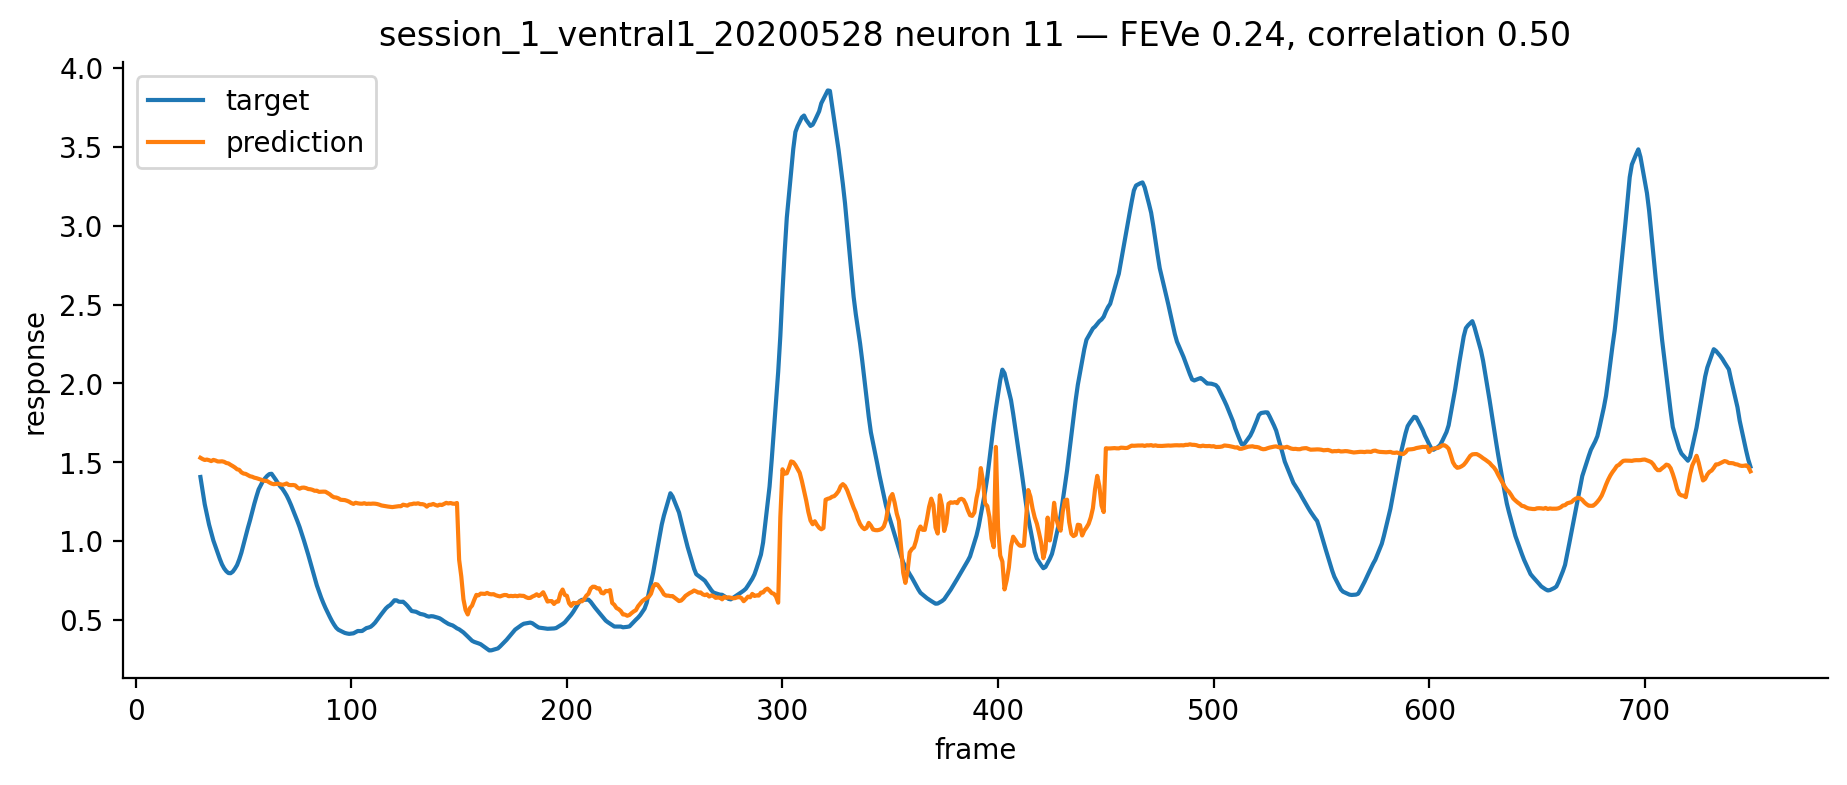

In [14]:
neuron_idx = int(np.argsort(feve_score)[-4])

mean_test_responses = final_responses[example_session].test_response  # (neurons, time)
window = model_predictions.shape[0]

plt.figure(figsize=(11, 4))
plt.plot(np.arange(lag, lag + window), mean_test_responses[neuron_idx, lag:][:window], label="target")
plt.plot(np.arange(lag, lag + window), model_predictions[:window, neuron_idx], label="prediction")
plt.xlabel("frame")
plt.ylabel("response")
plt.title(
    f"{example_session} neuron {neuron_idx} — "
    f"FEVe {feve_score[neuron_idx]:.2f}, correlation {correlations[neuron_idx]:.2f}"
)
plt.legend()
sns.despine()

# What the model actually learned

For an LNP the whole model *is* the readout: `nn.Conv3d(kernel_size=(1, 18, 16))`. In the greyscale
variant that is 1 x 18 x 16 = 288 weights per neuron mapping the current frame to the current
firing rate — a single achromatic spatial filter per neuron, and no temporal integration at all.
That is also the ceiling on what this model class can do, however it is regularized.

The colour model has two such filters per neuron (green and UV). Here `DummyCore` averages the
channels before the readout ever sees them, so the montage below has one panel instead of two and
the per-channel norm plot has a single bar.

The smoothness penalty (`smooth_weight`) acts directly on these filters via a spatial Laplacian, so
this is where the regularized and unregularized arms visibly differ: at the shipped default of
`1.0` the penalty is ~1e-4 of the loss and the filters stay speckled; at `3e4` they are spatially
coherent. `LaplaceL2norm` is the *ratio* `sum(laplace(w)^2) / sum(w^2)`, hence channel-count
invariant — which is why the colour model's best weight transferred unchanged to this half-size
model.

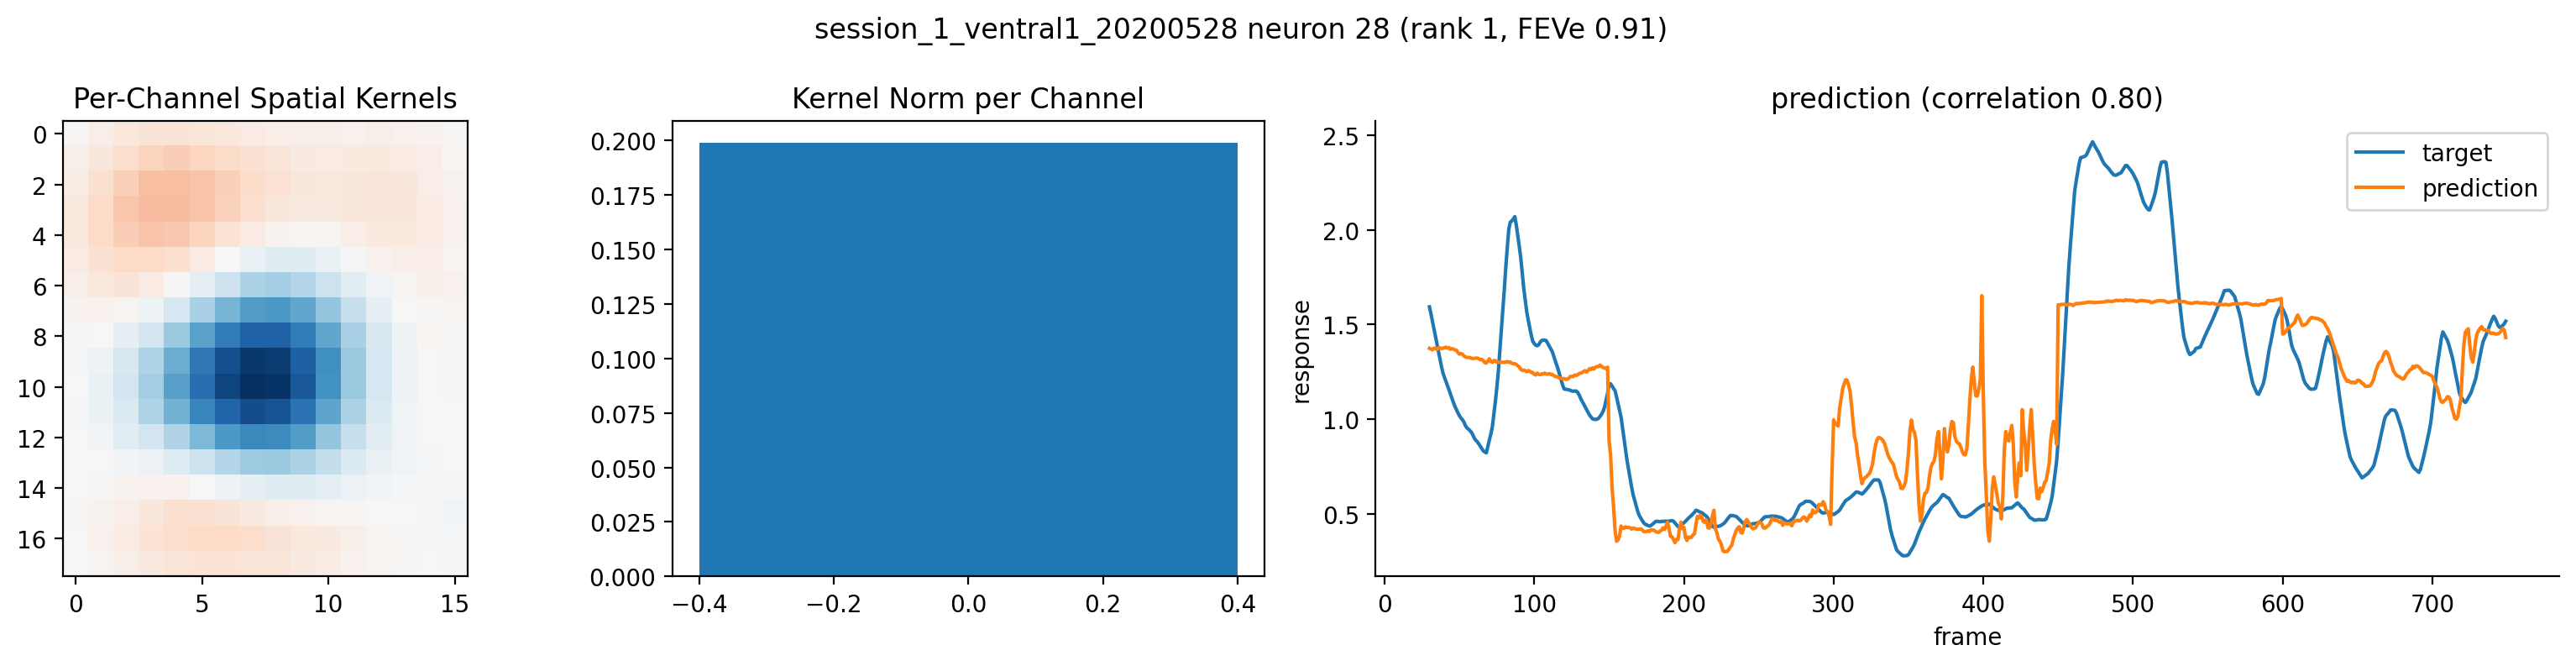

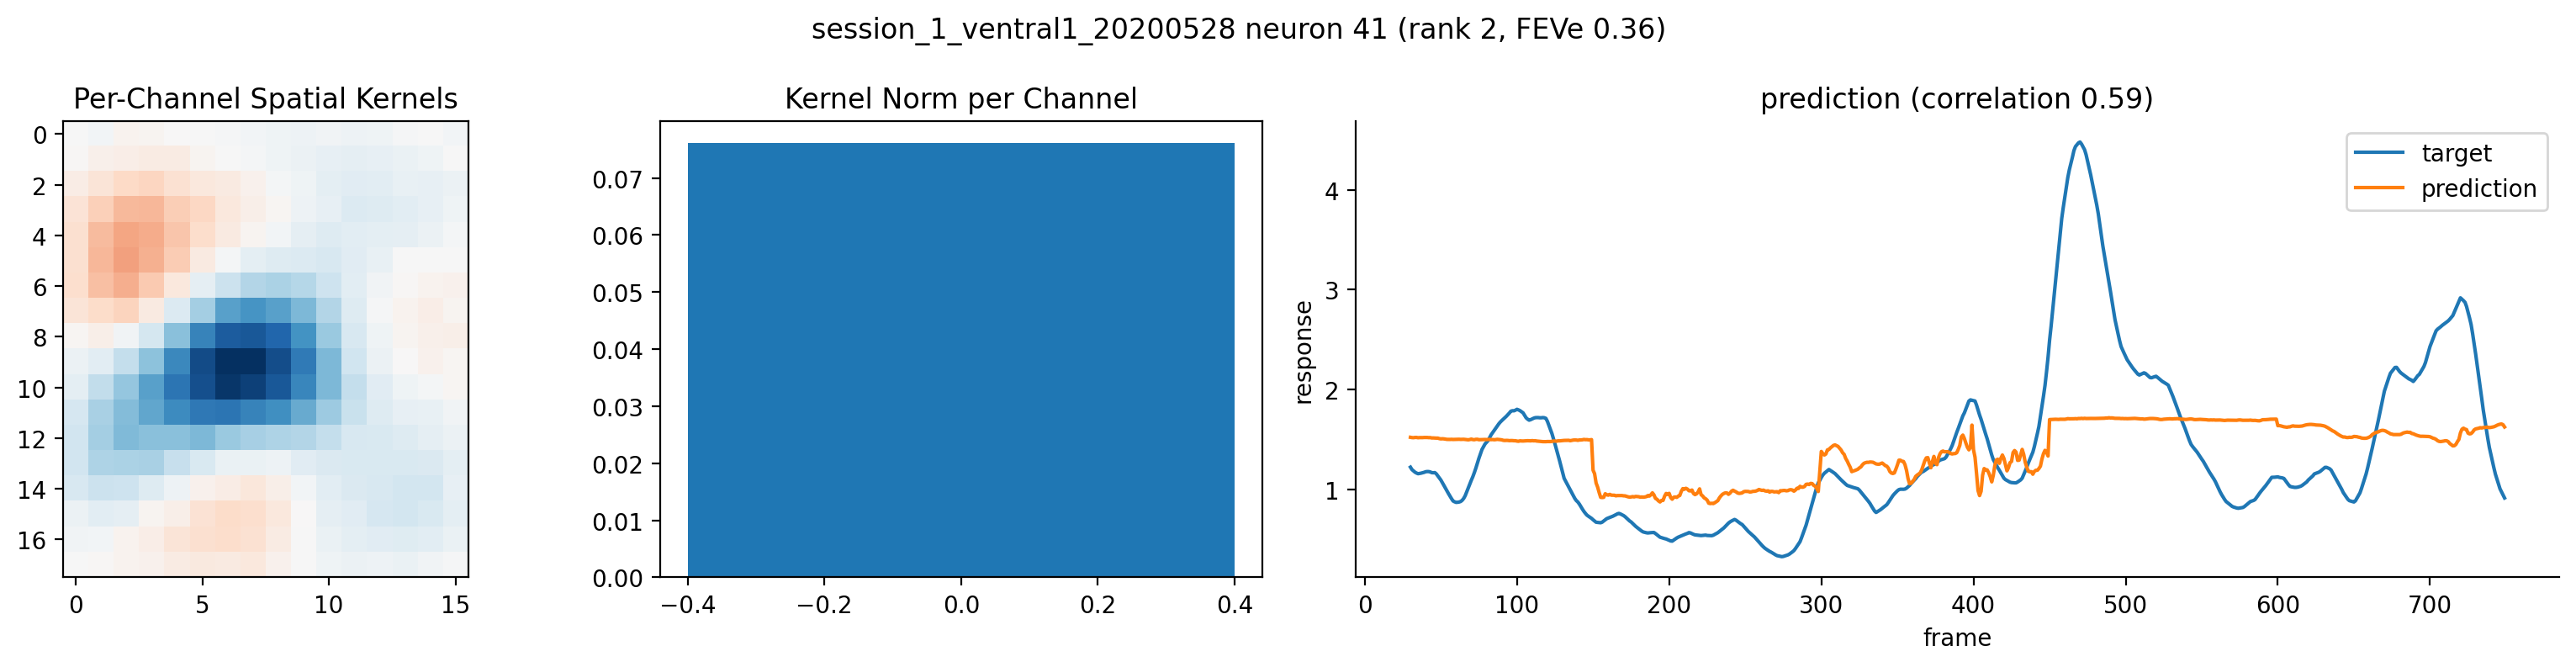

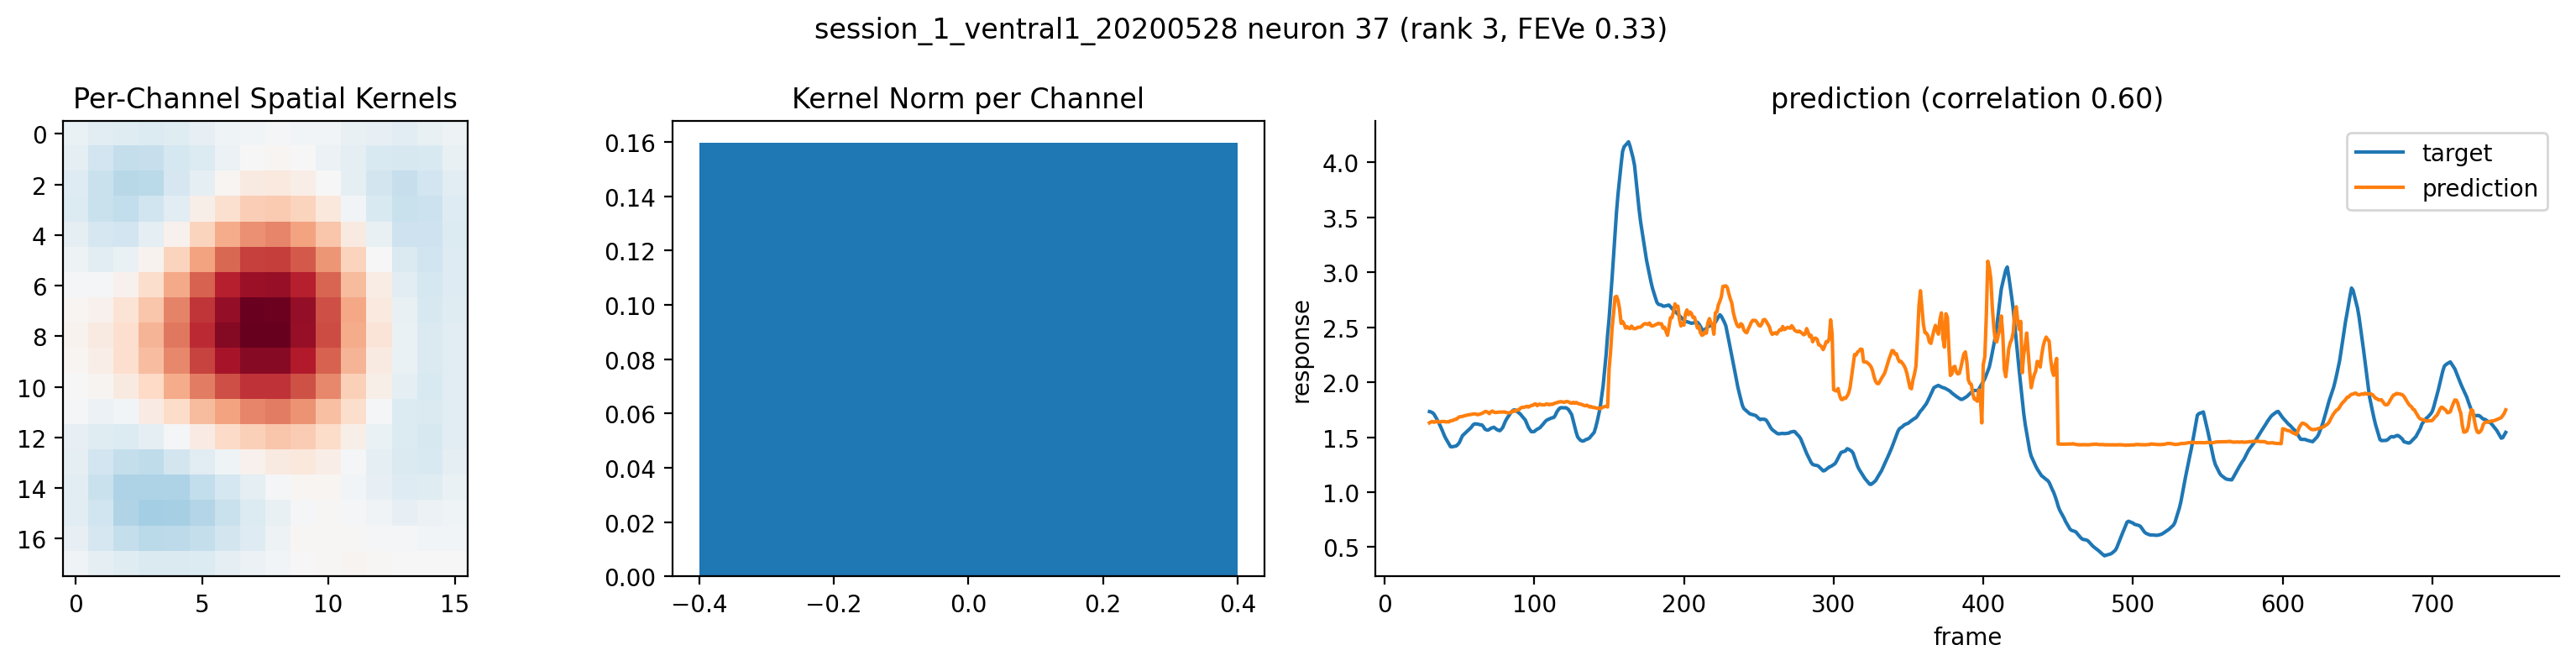

In [15]:
top_neurons = np.argsort(feve_score)[::-1][:3]

for rank, neuron in enumerate(top_neurons):
    # Lay the three panels out up front and hand the first two to the readout's plotting helper.
    # Left to itself it makes a 1x2 figure, so a 4th-of-4 subplot added afterwards lands on top of
    # the second panel instead of to the right of it.
    fig, (ax_readout, ax_features, resp_ax) = plt.subplots(
        ncols=3, figsize=(16, 4), gridspec_kw={"width_ratios": [1, 1, 2]}
    )
    model.readout[example_session].plot_weight_for_neuron(int(neuron), axes=(ax_readout, ax_features))

    resp_ax.plot(np.arange(lag, lag + window), mean_test_responses[neuron, lag:][:window], label="target")
    resp_ax.plot(np.arange(lag, lag + window), model_predictions[:window, neuron], label="prediction")
    resp_ax.set_xlabel("frame")
    resp_ax.set_ylabel("response")
    resp_ax.set_title(f"prediction (correlation {correlations[neuron]:.2f})")
    resp_ax.legend()
    sns.despine(ax=resp_ax)

    fig.suptitle(f"{example_session} neuron {neuron} (rank {rank + 1}, FEVe {feve_score[neuron]:.2f})")
    fig.tight_layout()
    plt.show()

---

## Evaluating a different checkpoint

Point `CKPT_PATH` at another arm and re-run from the *Loading the trained model* section — the data
above does not need reloading. Greyscale runs are laid out as
`openretina_assets/runs/lnp_grey/<jobid>/<arm>/checkpoints/`:

| job | arms | note |
|---|---|---|
| `442421` | `grey_base`, `grey_smooth3e4` | EarlyStopping `min_delta=1e-3`; `grey_base` was truncated at epoch 20 while still improving, so its 0.0873 val is a floor |
| `442473` | `grey_base`, `grey_smooth3e4` | `min_delta=1e-4`; the matched pair, and the source of the default above |

```python
# the unregularized greyscale arm, properly converged
CKPT_PATH = (
    "../openretina_assets/runs/lnp_grey/442473/grey_base/checkpoints/"
    "epoch=40_val_evaluation_loss=0.093_final.ckpt"
)
```

To compare against the **colour** model use `eval_hoefling_2024_lnp.ipynb` instead: it composes the
colour config, and its readout expects 2 channels. Loading a colour checkpoint here would trip the
greyscale assertion above, which is the point of it.

Published models can be loaded by name rather than path, e.g.
`load_core_readout_model("hoefling_2024_low_res", device)`.